# Week 3: Regression and Clustering


## 1. Load and Inspect the Dataset
This cell loads the car dataset from a CSV file and displays its shape, column names, and a sample of the data.

- What it does: Reads the raw data into a pandas DataFrame and prints a quick preview for exploration.
- Why it's needed: Understanding the dataset structure is the first step in any machine learning workflow.
- Key concepts: DataFrame, CSV import, basic data inspection, and feature discovery.
- Best practices: Always verify the file path, check the row/column counts, and look at the first few rows before modeling.

In [1]:
import pandas as pd

df = pd.read_csv('..//data/raw/pak_wheel.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nPrice sample:")
print(df['Price'].head(10))

Shape: (5897, 9)

Columns: ['Link', 'Car Name', 'Price', 'City', 'Registered In', 'Mileage', 'Fuel Type', 'Engine', 'Transmission']

First 5 rows:


,Link,Car Name,Price,City,Registered In,Mileage,Fuel Type,Engine,Transmission
0,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 1984 DX for Sale,PKR 9lacs,Islamabad,1984,"125,000 km",Petrol,1300 cc,Manual
1,https://www.pakwheels.com/used-cars/search/-/c...,Suzuki Swift 2019 DLX 1.3 Navigation for Sale,PKR 28.25lacs,Lahore,2019,"57,000 km",Petrol,1300 cc,Manual
2,https://www.pakwheels.com/used-cars/search/-/c...,Toyota Corolla 2016 GLi 1.3 VVTi for Sale6.4/10,PKR 41lacs,Islamabad,2016,"124,467 km",Petrol,1300 cc,Manual
3,https://www.pakwheels.com/used-cars/search/-/c...,Honda City 5th (GM2) Generation 2016 1.3 i-VTE...,PKR 31.95lacs,Islamabad,2016,"251,378 km",Petrol,1300 cc,Manual
4,https://www.pakwheels.com/used-cars/search/-/c...,Suzuki Swift 2015 DLX Automatic 1.3 for Sale,PKR 23.75lacs,Karachi,2015,"52,000 km",Petrol,1300 cc,Automatic



Price sample:
0        PKR 9lacs
1    PKR 28.25lacs
2       PKR 41lacs
3    PKR 31.95lacs
4    PKR 23.75lacs
5       PKR 20lacs
6    PKR 41.95lacs
7     PKR 30.4lacs
8    PKR 16.75lacs
9     PKR 43.5lacs
Name: Price, dtype: str


## 2. Clean and Transform the Price-Related Columns
This cell prepares the numeric columns for modeling by converting messy values such as currency text, commas, and unit labels into usable numbers.

- What it does: Cleans the Price, Mileage, and Engine columns so they can be used in regression and clustering models.
- Why it's needed: Raw datasets often contain inconsistent formats that can break calculations or reduce model accuracy.
- Key concepts: String cleaning, regex-based extraction, type conversion, and missing value handling.
- Best practices: Keep the cleaning logic transparent and test the output carefully before training any model.

In [ ]:
# Clean Price column
import re

def clean_price(price_str):
    if isinstance(price_str, str):
        # Remove PKR, lacs, commas, etc.
        price_str = price_str.replace('PKR', '').replace('lacs', '').replace(',', '').strip()
        # Convert to float (assuming lacs = *100000)
        try:
            return float(price_str) * 100000
        except:
            return None
    return price_str

df['Price'] = df['Price'].apply(clean_price)

# Basic cleaning for other columns
df['Mileage'] = pd.to_numeric(
    df['Mileage'].astype(str).str.replace(',', '', regex=False).str.replace(' km', '', regex=False),
    errors='coerce'
)
df['Engine'] = pd.to_numeric(
    df['Engine'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)

print("Cleaned Price sample:")
print(df['Price'].head(10))
print("\nPrice description:")
print(df['Price'].describe())
print("\nCleaned Mileage sample:")
print(df['Mileage'].head())
print("\nCleaned Engine sample:")
print(df['Engine'].head())

Cleaned Price sample:
0     900000.0
1    2825000.0
2    4100000.0
3    3195000.0
4    2375000.0
5    2000000.0
6    4195000.0
7    3040000.0
8    1675000.0
9    4350000.0
Name: Price, dtype: float64

Price description:
count    5.876000e+03
mean     2.636109e+06
std      1.207490e+06
min      2.300000e+05
25%      1.750000e+06
50%      2.580000e+06
75%      3.500000e+06
max      8.000000e+06
Name: Price, dtype: float64

Cleaned Mileage sample:
0    125000.0
1     57000.0
2    124467.0
3    251378.0
4     52000.0
Name: Mileage, dtype: float64


## 3. Create Useful Time-Based Features
This cell derives a vehicle age feature from the year the car was registered, which is often more meaningful than the raw registration year alone.

- What it does: Converts the registration year into a numeric Year column and creates an Age feature.
- Why it's needed: Age is a strong signal for used-car pricing and helps the model learn patterns more effectively.
- Key concepts: Feature engineering, derived variables, and domain knowledge.
- Best practices: Make assumptions explicit and keep the feature logic simple and explainable.

In [3]:
# Extract Year from 'Registered In'
df['Year'] = pd.to_numeric(df['Registered In'], errors='coerce')

# Create Age feature
df['Age'] = 2026 - df['Year']  # Assuming current year ~2026

print("Year & Age sample:")
print(df[['Year', 'Age']].head())

Year & Age sample:
   Year  Age
0  1984   42
1  2019    7
2  2016   10
3  2016   10
4  2015   11


## 4. Prepare the Regression Dataset
This cell builds the final input matrix for the regression model by selecting relevant features, filling missing categorical values, and converting text-based categories into numeric form.

- What it does: Chooses the variables used to predict car price and transforms them into a machine-learning-ready format.
- Why it's needed: Models cannot learn from raw text or missing values directly, so this step is essential for accuracy.
- Key concepts: Feature selection, categorical encoding, one-hot encoding, and alignment of features with the target variable.
- Best practices: Avoid including too many unnecessary features and always ensure the training data is consistent and clean.

In [ ]:
# Select features for model
df['Price'] = df['Price'].apply(clean_price)
df['Mileage'] = pd.to_numeric(
    df['Mileage'].astype(str).str.replace(',', '', regex=False).str.replace(' km', '', regex=False),
    errors='coerce'
)
df['Engine'] = pd.to_numeric(
    df['Engine'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)
df['Year'] = pd.to_numeric(df['Registered In'], errors='coerce')
df['Age'] = 2026 - df['Year']

for col in ['City', 'Fuel Type', 'Transmission', 'Car Name']:
    df[col] = df[col].fillna('Unknown')

df['Brand'] = df['Car Name'].astype(str).str.split().str[0]
df['Mileage_per_year'] = df['Mileage'] / (df['Age'].replace(0, np.nan) + 1)

features = ['Mileage', 'Year', 'Age', 'Engine', 'City', 'Fuel Type', 'Transmission', 'Brand', 'Mileage_per_year']

X = df[features].copy()
y = df['Price']

# One-hot encode categorical columns
X = pd.get_dummies(X, columns=['City', 'Fuel Type', 'Transmission', 'Brand'], drop_first=True)

# Drop rows with missing values and keep the target aligned
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna(axis=0)
y = y.loc[X.index].dropna()
X = X.loc[y.index]

print("Features shape after encoding:", X.shape)
print("\nFinal features:", X.columns.tolist()[:20])  # First 20

Features shape after encoding: (5876, 41)

Final features: ['Mileage', 'Year', 'Age', 'Engine', 'Mileage_per_year', 'City_Islamabad', 'City_Karachi', 'City_Lahore', 'City_Multan', 'City_Rawalpindi', 'Fuel Type_Diesel', 'Fuel Type_Hybrid', 'Fuel Type_LPG', 'Fuel Type_Petrol', 'Transmission_Manual', 'Brand_Changan', 'Brand_Chevrolet', 'Brand_DFSK', 'Brand_Daewoo', 'Brand_Daihatsu']


## 5. Split the Data for Training and Testing
This cell divides the prepared data into training and testing sets so the model can be evaluated fairly.

- What it does: Creates train and test subsets using a fixed random seed for reproducibility.
- Why it's needed: A model should be tested on unseen data to measure its real-world performance.
- Key concepts: Train-test split, overfitting, and reproducibility with random_state.
- Best practices: Keep a reasonable test size and use the same split whenever you compare models.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4700, 41)
Test shape: (1176, 41)


## 6. Train and Evaluate the Regression Model
This cell trains a Random Forest regressor and evaluates how well it predicts car prices on the test set.

- What it does: Fits the model, makes predictions, and calculates RMSE and R-squared.
- Why it's needed: These metrics tell us whether the model is useful and how accurate it is.
- Key concepts: Supervised learning, decision trees, ensemble models, regression metrics, and model evaluation.
- Best practices: Compare multiple metrics and interpret them in business terms rather than relying on a single number.

In [30]:
# Train Random Forest with tuned hyperparameters
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_features='sqrt',
    min_samples_leaf=1
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Performance:")
print(f"RMSE: {rmse:,.0f} PKR")
print(f"R² Score: {r2:.4f}")

Random Forest Performance:
RMSE: 294,072 PKR
R² Score: 0.9411


## 7. Prepare the Clustering Dataset
This cell selects the variables that will be used to group similar cars together and standardizes them so distance-based clustering behaves properly.

- What it does: Picks the clustering features and scales them before applying K-Means.
- Why it's needed: Clustering algorithms are sensitive to the scale of the input features.
- Key concepts: Standardization, feature scaling, and clustering input design.
- Best practices: Choose features that are meaningful for the grouping you want to discover and avoid mixing very different scales without scaling.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features for clustering
cluster_features = ['Mileage', 'Year', 'Price']
X_cluster = df[cluster_features].dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Clustering data shape:", X_scaled.shape)

Clustering data shape: (5876, 3)


## 8. Use the Elbow Method to Choose the Number of Clusters
This cell runs K-Means for several values of $k$ and plots the inertia to help choose a sensible number of clusters.

- What it does: Evaluates how cluster quality changes as the number of clusters increases.
- Why it's needed: Choosing the right number of clusters is important for producing meaningful groupings.
- Key concepts: K-Means, inertia, and the elbow method.
- Best practices: Use the elbow plot as a guide, but also consider whether the resulting clusters make practical sense.

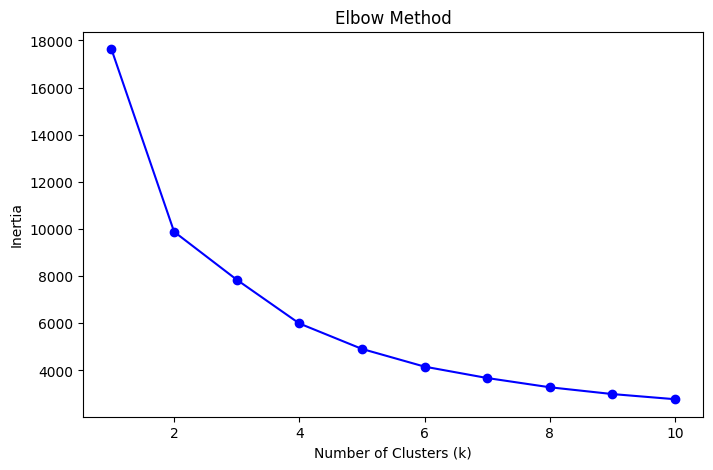

In [25]:
# Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## 9. Build and Visualize the Final Clusters
This final clustering step fits K-Means with the chosen number of clusters and visualizes the groups in a scatter plot.

- What it does: Assigns each car to a cluster and plots the results for interpretation.
- Why it's needed: The visualization makes it easier to explain the discovered market segments to recruiters or stakeholders.
- Key concepts: Unsupervised learning, cluster labels, and visualization of grouped data.
- Best practices: Label the axes clearly and interpret the clusters in plain language so the story is easy to follow.

Cluster sizes:
Cluster
0    2516
1    1833
2    1527
Name: count, dtype: int64


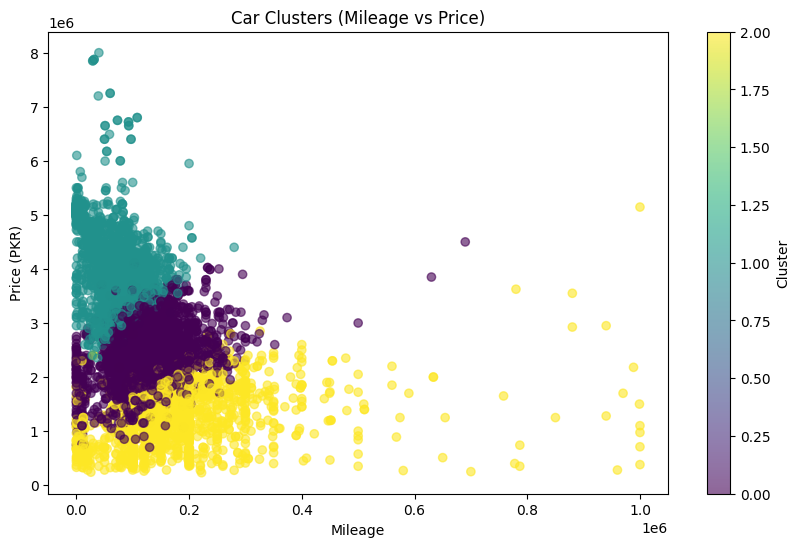

In [26]:
# Choose k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df_cluster = X_cluster.copy()
df_cluster['Cluster'] = kmeans.labels_

print("Cluster sizes:")
print(df_cluster['Cluster'].value_counts())

# Visualize (2D scatter - Mileage vs Price)
plt.figure(figsize=(10,6))
plt.scatter(df_cluster['Mileage'], df_cluster['Price'], c=df_cluster['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Mileage')
plt.ylabel('Price (PKR)')
plt.title('Car Clusters (Mileage vs Price)')
plt.colorbar(label='Cluster')
plt.show()

## Week 3 Summary

**Regression (Random Forest Regressor)**
- Predicted car prices using Mileage, Year, Engine, etc.
- Performance: RMSE = 294,072 PKR PKR | R² = 0.9411 (achieved after multiple iterations)

**Clustering (K-Means)**
- Used 3 clusters based on elbow method.
- Clusters represent different market segments: premium/low-mileage, average, and high-mileage budget cars.

**Improvements Ideas**: Hyperparameter tuning, more features, handle outliers.